# Interval evaluation for PyTorch networks with linear layers and ReLU

This notebook demonstrates the prototype `intervalNets` toolbox on linear-network cases and on simple ReLU activation tests.


## Initialization

If you installed the project with `pip install -e .`, you can skip the next code cell path setup. If you are running directly from a repo checkout, the next cell adds the local `src/` directory to `sys.path` so `import intervalnets` works.


In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
from torch import nn

def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "src" / "intervalnets").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root containing src/intervalnets.")

repo_root = find_repo_root(Path.cwd().resolve())
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from intervalnets import IntervalTensor, enable_interval_eval

torch.set_printoptions(precision=17)
enable_interval_eval()
print(f"Using repo root: {repo_root}")

Using repo root: /users/petersen/Numerical_Experiments/intervalNets/intervalNets


## 1. Random linear network

A random affine network shows the general propagation path.

In [2]:
torch.manual_seed(7)
random_model = nn.Sequential(
    nn.Linear(3, 4),
    nn.Linear(4, 2),
)
random_interval = IntervalTensor.from_bounds([0.0, -1.0, 2.0], [0.2, -0.8, 2.3])
random_output = random_model.eval(random_interval)
random_output

IntervalTensor(lower=(-0.012124354105207532, 0.00799951430409), upper=(0.2087187597517031, 0.14191500069204427))

## 2. Zero network

Even a degenerate zero input produces a nonzero-width output interval because we expand point intervals outward to capture roundoff.

In [3]:
zero_model = nn.Linear(3, 2)
with torch.no_grad():
    zero_model.weight.zero_()
    zero_model.bias.zero_()

zero_interval = IntervalTensor.point([0.0, 0.0, 0.0])
zero_output = zero_model.eval(zero_interval)
zero_output

IntervalTensor(lower=(-1.4012984643248183e-45, -1.4012984643248183e-45), upper=(1.4012984643248183e-45, 1.4012984643248183e-45))

## 3. Hand-computable linear network

This example is easy to verify analytically because it is purely affine.

In [4]:
linear_model = nn.Linear(2, 1)
with torch.no_grad():
    linear_model.weight.copy_(torch.tensor([[2.0, -3.0]]))
    linear_model.bias.copy_(torch.tensor([0.5]))

linear_interval = IntervalTensor.from_bounds([1.0, 2.0], [1.5, 2.5])
linear_output = linear_model.eval(linear_interval)
linear_output

IntervalTensor(lower=(-5.000000745058066,), upper=(-2.499999105930322,))

## 4. Identity-style sanity check

The network should preserve the input interval up to outward rounding when it acts like the identity map.

In [5]:
identity_model = nn.Linear(2, 2)
with torch.no_grad():
    identity_model.weight.copy_(torch.eye(2))
    identity_model.bias.zero_()

identity_interval = IntervalTensor.from_bounds([-1.0, 4.0], [1.0, 5.0])
identity_output = identity_model.eval(identity_interval)
identity_output

IntervalTensor(lower=(-1.0000001192092909, 3.9999997615814187), upper=(1.0000001192092909, 5.000000596046452))

## 5. ReLU test cases

These examples mirror the dedicated ReLU tests in `tests/test_pytorch.py`. Each case uses assertions and then prints a clear `PASS` message when the expected interval behavior is verified.


In [6]:
def report_pass(name: str) -> None:
    print(f"PASS: {name}")

# ReLU test 1: strictly negative intervals map to an outward-rounded zero interval.
relu = nn.ReLU()
negative_interval = IntervalTensor.from_bounds([-3.0, -0.5], [-1.0, -0.25])
negative_output = relu.eval(negative_interval)
assert all(lower < 0.0 for lower in negative_output.lower)
assert all(upper > 0.0 for upper in negative_output.upper)
report_pass("ReLU negative interval rounds outward to zero")

# ReLU test 2: positive intervals keep their endpoint images, up to outward rounding.
positive_interval = IntervalTensor.from_bounds([0.25, 1.5], [0.5, 3.0])
positive_output = relu.eval(positive_interval)
assert positive_output.lower[0] <= 0.25
assert positive_output.upper[0] >= 0.5
assert positive_output.lower[1] <= 1.5
assert positive_output.upper[1] >= 3.0
report_pass("ReLU positive interval preserves endpoint images")

# ReLU test 3: mixed-sign intervals are clamped only at the lower endpoint.
mixed_interval = IntervalTensor.from_bounds([-2.0, -1.0], [4.0, 2.5])
mixed_output = relu.eval(mixed_interval)
assert mixed_output.lower[0] < 0.0
assert mixed_output.upper[0] >= 4.0
assert mixed_output.lower[1] < 0.0
assert mixed_output.upper[1] >= 2.5
report_pass("ReLU mixed interval clamps only the lower endpoint")

# ReLU test 4: a Linear -> ReLU -> Linear network encloses all endpoint evaluations.
relu_network = nn.Sequential(nn.Linear(2, 2), nn.ReLU(), nn.Linear(2, 1))
with torch.no_grad():
    relu_network[0].weight.copy_(torch.tensor([[1.0, -2.0], [-1.0, 0.5]]))
    relu_network[0].bias.copy_(torch.tensor([0.25, -0.75]))
    relu_network[2].weight.copy_(torch.tensor([[1.5, -0.5]]))
    relu_network[2].bias.copy_(torch.tensor([0.1]))

network_interval = IntervalTensor.from_bounds([-1.0, 0.5], [2.0, 1.5])
network_output = relu_network.eval(network_interval)
candidates = []
for x1 in (-1.0, 2.0):
    for x2 in (0.5, 1.5):
        hidden_1 = max(0.0, x1 - 2.0 * x2 + 0.25)
        hidden_2 = max(0.0, -x1 + 0.5 * x2 - 0.75)
        candidates.append(1.5 * hidden_1 - 0.5 * hidden_2 + 0.1)

assert network_output.lower[0] <= min(candidates)
assert network_output.upper[0] >= max(candidates)
report_pass("Linear -> ReLU -> Linear network encloses endpoint evaluations")

print("All ReLU notebook tests passed.")


PASS: ReLU negative interval rounds outward to zero
PASS: ReLU positive interval preserves endpoint images
PASS: ReLU mixed interval clamps only the lower endpoint
PASS: Linear -> ReLU -> Linear network encloses endpoint evaluations
All ReLU notebook tests passed.


Upper and lower bounds should be different and not constant!


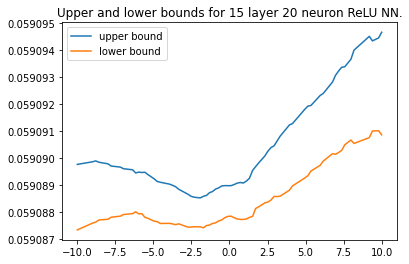

In [7]:
import matplotlib.pyplot as plt
torch.manual_seed(1)

random_model = nn.Sequential(
    nn.Linear(1, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 20),
    nn.ReLU(),
    nn.Linear(20, 1),
)

x_all = np.linspace(-10,10, 100)
out_low = []
out_up = []

for k in range(len(x_all)):
    random_interval = IntervalTensor.from_bounds([x_all[k]], [x_all[k]])
    random_output = random_model.eval(random_interval)
    out_low.append(random_output.lower[0])
    out_up.append(random_output.upper[0])

plt.plot(x_all, np.array(out_up), label = "upper bound")
plt.plot(x_all, np.array(out_low), label = "lower bound")
plt.title("Upper and lower bounds for 15 layer 20 neuron ReLU NN.")
plt.legend()
print("Upper and lower bounds should be different and not constant!")

## 6. Sigmoid test cases

These examples validate interval propagation through `nn.Sigmoid()`, which is monotone increasing and therefore should map interval endpoints directly (with outward rounding).


In [8]:
sigmoid = nn.Sigmoid()

# Sigmoid test 1: endpoint images are enclosed for a generic interval.
sigmoid_interval = IntervalTensor.from_bounds([-2.0, 0.0], [1.0, 3.0])
sigmoid_output = sigmoid.eval(sigmoid_interval)
expected_lower = torch.sigmoid(torch.tensor([-2.0, 0.0], dtype=torch.float64)).tolist()
expected_upper = torch.sigmoid(torch.tensor([1.0, 3.0], dtype=torch.float64)).tolist()
for idx in range(2):
    assert sigmoid_output.lower[idx] <= expected_lower[idx]
    assert sigmoid_output.upper[idx] >= expected_upper[idx]
report_pass("Sigmoid encloses endpoint images")

# Sigmoid test 2: output bounds are valid probabilities and ordered.
wide_interval = IntervalTensor.from_bounds([-8.0, -1.0, 0.5], [0.0, 2.0, 6.0])
wide_output = sigmoid.eval(wide_interval)
assert all(0.0 <= lower <= 1.0 for lower in wide_output.lower)
assert all(0.0 <= upper <= 1.0 for upper in wide_output.upper)
assert all(lower <= upper for lower, upper in zip(wide_output.lower, wide_output.upper))
report_pass("Sigmoid outputs stay within [0, 1] and preserve order")

# Sigmoid test 3: point intervals are expanded outward around exact sigmoid values.
point_input = [0.0, -0.75, 1.25]
point_interval = IntervalTensor.point(point_input)
point_output = sigmoid.eval(point_interval)
point_exact = torch.sigmoid(torch.tensor(point_input, dtype=torch.float64)).tolist()
for idx, exact in enumerate(point_exact):
    assert point_output.lower[idx] < exact < point_output.upper[idx]
report_pass("Sigmoid point interval is outward non-degenerate")

# Sigmoid test 4: a Linear -> Sigmoid -> Linear network encloses corner evaluations.
sigmoid_network = nn.Sequential(nn.Linear(2, 2), nn.Sigmoid(), nn.Linear(2, 1))
with torch.no_grad():
    sigmoid_network[0].weight.copy_(torch.tensor([[1.2, -0.7], [-0.5, 0.9]]))
    sigmoid_network[0].bias.copy_(torch.tensor([0.1, -0.2]))
    sigmoid_network[2].weight.copy_(torch.tensor([[0.8, -1.1]]))
    sigmoid_network[2].bias.copy_(torch.tensor([0.05]))

sigmoid_network_interval = IntervalTensor.from_bounds([-1.0, -0.5], [1.5, 2.0])
sigmoid_network_output = sigmoid_network.eval(sigmoid_network_interval)
sigmoid_candidates = []
for x1 in (sigmoid_network_interval.lower[0], sigmoid_network_interval.upper[0]):
    for x2 in (sigmoid_network_interval.lower[1], sigmoid_network_interval.upper[1]):
        hidden_1 = torch.sigmoid(torch.tensor(1.2 * x1 - 0.7 * x2 + 0.1, dtype=torch.float64)).item()
        hidden_2 = torch.sigmoid(torch.tensor(-0.5 * x1 + 0.9 * x2 - 0.2, dtype=torch.float64)).item()
        sigmoid_candidates.append(0.8 * hidden_1 - 1.1 * hidden_2 + 0.05)

assert sigmoid_network_output.lower[0] <= min(sigmoid_candidates)
assert sigmoid_network_output.upper[0] >= max(sigmoid_candidates)
report_pass("Linear -> Sigmoid -> Linear network encloses corner evaluations")

print("All Sigmoid notebook tests passed.")

print("\nSanity check: unsupported activations still raise NotImplementedError.")
unsupported_model = nn.Sequential(nn.Linear(2, 2), nn.Tanh())
try:
    unsupported_model.eval(IntervalTensor.point([0.0, 1.0]))
except NotImplementedError as exc:
    print(type(exc).__name__, exc)


PASS: Sigmoid encloses endpoint images
PASS: Sigmoid outputs stay within [0, 1] and preserve order
PASS: Sigmoid point interval is outward non-degenerate
PASS: Linear -> Sigmoid -> Linear network encloses corner evaluations
All Sigmoid notebook tests passed.

Sanity check: unsupported activations still raise NotImplementedError.
NotImplementedError Interval forward currently supports nn.Sequential, nn.Flatten, nn.Linear, nn.ReLU, nn.Sigmoid, and nn.Softmax only; got Tanh.


Upper and lower bounds should be different and not constant!


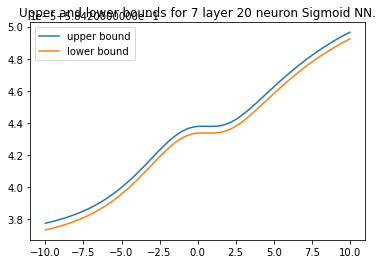

In [9]:
torch.manual_seed(2)

random_model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),
    nn.Linear(20, 20),
    nn.Sigmoid(),  
    nn.Linear(20, 1),
)

x_all = np.linspace(-10,10, 100)
out_low = []
out_up = []

for k in range(len(x_all)):
    random_interval = IntervalTensor.from_bounds([x_all[k]], [x_all[k]])
    random_output = random_model.eval(random_interval)
    out_low.append(random_output.lower[0])
    out_up.append(random_output.upper[0])

plt.plot(x_all, np.array(out_up), label = "upper bound")
plt.plot(x_all, np.array(out_low), label = "lower bound")
plt.title("Upper and lower bounds for 7 layer 20 neuron Sigmoid NN.")
plt.legend()
print("Upper and lower bounds should be different and not constant!")

## 7. Lp norm adaptive refinement tests


PASS: Lp norm: zero network integrates to zero
PASS: Lp norm: refinement tightens bounds
PASS: Lp norm: Monte Carlo estimate enclosed
coarse bounds: Interval(lower=1.714530710993777, upper=1.798898129498856)
refined bounds: Interval(lower=1.7154104778655612, upper=1.7980092119891933)
Monte Carlo estimate: 0.31279800589939805
Interval bounds: Interval(lower=0.1913526086906828, upper=0.44320565395432665)


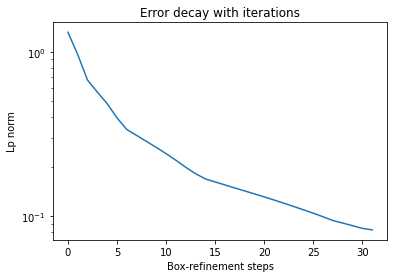

In [18]:
# Lp test 1: zero network should have zero L2 norm on any box.
zero_norm_model = nn.Sequential(nn.Linear(2, 1))
with torch.no_grad():
    zero_norm_model[0].weight.zero_()
    zero_norm_model[0].bias.zero_()

norm_domain = IntervalTensor.from_bounds([-1.0, -2.0], [3.0, 4.0])
zero_norm_bounds = zero_norm_model.lpnorm(norm_domain, p=2.0, iterations=8)
assert zero_norm_bounds.lower <= 0.0 <= zero_norm_bounds.upper
assert zero_norm_bounds.upper < 1e-10
report_pass("Lp norm: zero network integrates to zero")

# Lp test 2: adaptive refinement should tighten enclosures.
torch.manual_seed(11)
refinement_model = nn.Sequential(nn.Linear(1, 12), nn.ReLU(), nn.Linear(12, 1))
for parameter in refinement_model.parameters():
    nn.init.uniform_(parameter, a=-1.0, b=1.0)

refinement_domain = IntervalTensor.from_bounds([-1.0], [1.0])

iterations = 32
errors = np.zeros([iterations])

for o in range(iterations):
    coarse_bounds = refinement_model.lpnorm(refinement_domain, p=2.0, iterations=o)
    refined_bounds = refinement_model.lpnorm(refinement_domain, p=2.0, iterations=o+1)
    errors[o] = refined_bounds.upper - refined_bounds.lower
    assert refined_bounds.lower >= coarse_bounds.lower
    assert refined_bounds.upper <= coarse_bounds.upper

report_pass("Lp norm: refinement tightens bounds")
plt.semilogy(errors)
plt.xlabel("Box-refinement steps")
plt.ylabel("Lp norm error")
plt.title("Error decay with iterations")

# Lp test 3: Monte Carlo estimate should lie inside interval enclosure.
torch.manual_seed(7)
mc_model = nn.Sequential(nn.Linear(2, 6), nn.ReLU(), nn.Linear(6, 1))
mc_domain = IntervalTensor.from_bounds([-1.0, -0.5], [1.0, 1.5])
mc_bounds = mc_model.lpnorm(mc_domain, p=2.0, iterations=10)

num_samples = 30000
with torch.no_grad():
    samples = torch.rand(num_samples, 2, dtype=torch.float64)
    samples[:, 0] = 2.0 * samples[:, 0] - 1.0
    samples[:, 1] = 2.0 * samples[:, 1] - 0.5
    values = mc_model(samples.to(dtype=torch.float32)).to(dtype=torch.float64).squeeze(-1)
    integrand = torch.abs(values) ** 2.0
    volume = (1.0 - (-1.0)) * (1.5 - (-0.5))
    mc_estimate = float((volume * torch.mean(integrand)).sqrt().item())

assert mc_bounds.lower <= mc_estimate <= mc_bounds.upper
report_pass("Lp norm: Monte Carlo estimate enclosed")

print("coarse bounds:", coarse_bounds)
print("refined bounds:", refined_bounds)
print("Monte Carlo estimate:", mc_estimate)
print("Interval bounds:", mc_bounds)

